In [1]:
import pandas as pd
import numpy as np
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

2026-06-23 11:11:53.331357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782213113.511157      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782213113.563913      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782213113.981544      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782213113.981583      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782213113.981585      58 computation_placer.cc:177] computation placer alr

In [3]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [4]:
print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

GPUs Available: 2


In [5]:
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files[:10]:
        print(os.path.join(root, file))

/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav


In [6]:
dataset_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"

In [7]:
emotion_dict = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}
paths = []
emotions = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        if filename.endswith('.wav'):
            emotion = emotion_dict[
                filename.split('-')[2]
            ]
            paths.append(
                os.path.join(dirname, filename)
            )
            emotions.append(emotion)

In [8]:
df = pd.DataFrame({
    "Path": paths,
    "Emotion": emotions
})
df.head()

,Path,Emotion
0,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,surprised
1,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral
2,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
3,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
4,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral


In [9]:
df.shape

(2880, 2)

In [10]:
df["Emotion"].value_counts()

Emotion
surprised    384
disgust      384
fearful      384
sad          384
happy        384
calm         384
angry        384
neutral      192
Name: count, dtype: int64

In [11]:
def extract_features(path):
    audio, sample_rate = librosa.load(
        path,
        duration=3,
        offset=0.5
    )
    mfcc = np.mean(
        librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )
    return mfcc

In [12]:
X = []
for path in df["Path"]:
    feature = extract_features(path)
    X.append(feature)

In [13]:
X = np.array(X)
print(X.shape)

(2880, 40)


In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df["Emotion"])
print(y[:10])

[7 5 2 2 5 3 6 5 1 4]


In [15]:
for i, emotion in enumerate(encoder.classes_):
    print(i, emotion)

0 angry
1 calm
2 disgust
3 fearful
4 happy
5 neutral
6 sad
7 surprised


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(2304, 40)
(576, 40)


In [18]:
print(X.shape)

(2880, 40)


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
model = Sequential([
    Input(shape=(40,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(8, activation='softmax')
])

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2018 - loss: 2.0400 - val_accuracy: 0.3021 - val_loss: 1.8500
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2925 - loss: 1.8230 - val_accuracy: 0.4167 - val_loss: 1.6297
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3494 - loss: 1.6895 - val_accuracy: 0.4410 - val_loss: 1.4891
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4084 - loss: 1.5612 - val_accuracy: 0.5017 - val_loss: 1.3548
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4505 - loss: 1.4743 - val_accuracy: 0.5434 - val_loss: 1.2770
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4813 - loss: 1.3907 - val_accuracy: 0.5764 - val_loss: 1.2101
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5009 - loss: 1.3309 - val_accuracy: 0.5955 - val_loss: 1.1518
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5156 - loss: 1.2714 - val_accuracy: 0.6302 - val_loss:

In [26]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("Test Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7674 - loss: 0.6734 
Test Accuracy: 0.7673611044883728


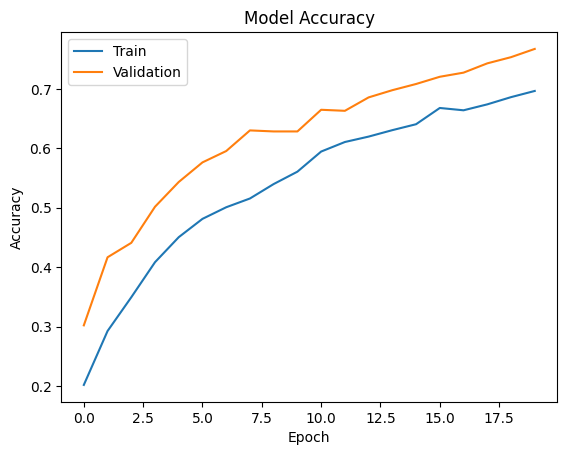

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


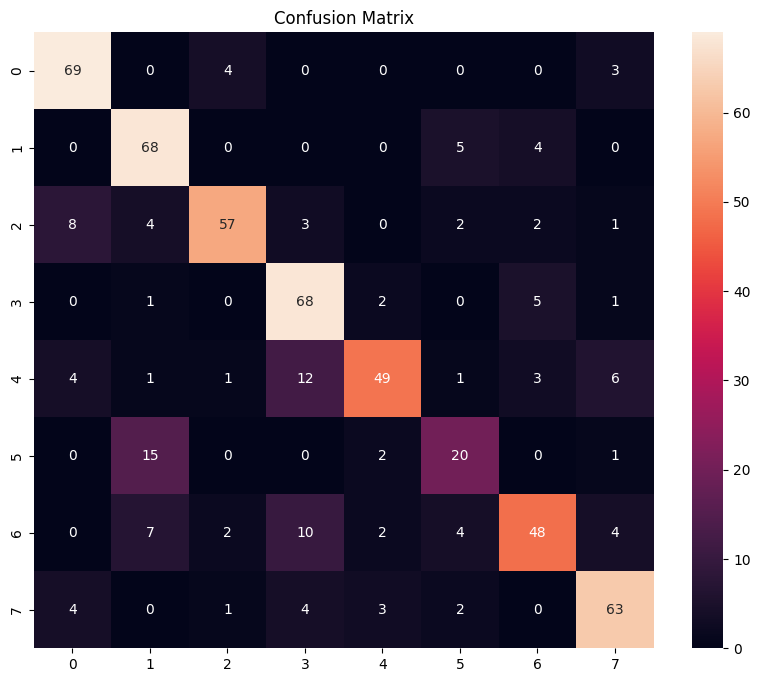

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(
    y_test,
    y_pred_classes
)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title("Confusion Matrix")
plt.show()

In [30]:
model.save(
    "emotion_recognition_model.keras"
)

In [31]:
import os
os.listdir()

['emotion_recognition_model.keras',
 '.virtual_documents',
 'emotion_recognition_model.h5']